# Contact Validation
## Linear Elasticity with Contact



In [101]:
import imp
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve.solvers import Newton, NewtonMinimization
from netgen.webgui import Draw as DrawGeo

In [102]:
rect_len_x = 0.5
rect_len_y = 0.1
r_ball = 0.1
h0_ball = 0.225
g = 9.81

rect = MoveTo(-rect_len_x/2, 0).Rectangle(rect_len_x, rect_len_y).Face()
rect.edges.Max(Y).maxh = r_ball/15
rect.edges.Max(Y).name = "contact_wall"
rect.edges.Min(Y).name = "fix"
rect.edges.Max(X).name = "free"
rect.name = "wall"

ball = Circle((0, h0_ball), r_ball).Face()
ball.edges.Max(Y).maxh = r_ball/15
ball.edges.name = "contact_ball"
ball.name = "ball"

# Cut at y=0 for symmetry
sym_cut = MoveTo(-rect_len_x/2,0).Rectangle(rect_len_x/2, rect_len_y + h0_ball + r_ball).Face()
sym_cut.edges.Max(X).name = "sym"

rect = rect - sym_cut
ball = ball - sym_cut

geo = Compound([ball, rect])
geo = OCCGeometry(geo, dim = 2)
mesh = Mesh(geo.GenerateMesh(maxh=0.025))
mesh.Curve(3)
Draw(mesh)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [103]:
E, nu = 210e6, 0.2
rho = 7000
thickness = 1
mu  = E / 2 / (1+nu)
lam = E * nu / ((1+nu)*(1-2*nu))

def eps(u):
    return Sym(Grad(u))

def linear_elastic_strain_energy_density(eps):
    return 0.5*lam*Trace(eps)**2 + mu*InnerProduct(eps, eps)

def kinetic_energy_density(vel):
    return 0.5 * rho * InnerProduct(vel, vel)

def gravitational_energy_density_current(u):
    # y_current = y + u_y
    return rho * g * (y + u[1])

In [104]:
fes = VectorH1(mesh, order=3, dirichletx="sym", dirichlety="fix")
u,v = fes.TnT()

force = CF((0,-g*rho*thickness))

uold = GridFunction(fes)
unew = GridFunction(fes)
vel = GridFunction(fes)
vold = GridFunction(fes)
anew = GridFunction(fes)
aold = GridFunction(fes)

tau = 2e-4

bfmstar = BilinearForm(fes)
bfmstar += Variation( linear_elastic_strain_energy_density(eps(u)).Compile(False)*dx )
#bfmstar += Variation( -force*u*dx("ball") )
bfmstar += Variation( -force * 0.5*(u + uold) * dx("ball") )
bfmstar += Variation( rho/2 * 2/tau**2 * (u - uold - tau*vel -tau**2/4*aold)**2 * dx("ball") )

tend = 0.35
t = 0
unew.Set( (0,0) )
vel.Set( (0,0) )

kn = 1e11 # penalty stiffness
master = mesh.Boundaries("contact_wall")
slave = mesh.Boundaries("contact_ball")

contact = ContactBoundary(master, slave)

# Incremental gap
X = CoefficientFunction((x, y)) # Reference configuration master
cur_pos_master = X + u-uold
cur_pos_slave  = X.Other() + u.Other() - uold.Other()
n_S = -specialcf.normal(2).Other()
cf = (cur_pos_master - cur_pos_slave) * n_S
penalty_energy = kn * cf * cf
contact.AddEnergy(IfPos(cf, penalty_energy, 0), deformed=True)

area_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
print("Area ball:", area_ball)

time_hist = []
E_kin_hist, E_ela_hist, E_grav_hist, E_tot_hist = [], [], [], []
E_kin_mid_hist = [] 
vy_cm_hist = []

scene = Draw (unew,
              mesh,
              "disp", 
              deformation=unew,
              autoscale=False,
              min = 0, max=0.025)
i = 0
with TaskManager():
    while t < tend:
        t += tau
        
        uold.vec.data = unew.vec
        vold.vec.data = vel.vec
        aold.vec.data = anew.vec

        contact.Update(uold, bfmstar, 5, 0.01)
        NewtonMinimization (a=bfmstar, u=unew, printing=False, inverse="sparsecholesky")

        anew.vec.data  = unew.vec - uold.vec - tau*vel.vec - (tau**2/4)*aold.vec
        anew.vec.data *= 4/tau**2
        vel.vec.data  += 0.5*tau*aold.vec
        vel.vec.data  += 0.5*tau*anew.vec
        
        # Mid point velocity
        u_mid = 0.5 * (uold + unew)
        v_mid = 0.5 * (vold + vel)
        
        # Energies
        E_kin_mid = Integrate(0.5 * rho * InnerProduct(v_mid, v_mid), mesh, definedon=mesh.Materials("ball"))
        E_ela = Integrate(linear_elastic_strain_energy_density(eps(unew)), mesh)
        E_grav = Integrate( gravitational_energy_density_current(u_mid), mesh, definedon=mesh.Materials("ball") )
        E_tot = E_kin_mid + E_ela + E_grav
        
        vy_avg = Integrate(vel[1], mesh, definedon=mesh.Materials("ball")) / area_ball
        
        time_hist.append(t)
        E_kin_mid_hist.append(E_kin_mid)
        E_ela_hist.append(E_ela)
        E_grav_hist.append(E_grav)
        E_tot_hist.append(E_tot)
        
        vy_cm_hist.append(vy_avg)
        
        if i % 20 == 0:
            print(f"t {t:.4f}, E_kin: {E_kin_mid:.4f} E_ela: {E_ela:.4f}, E_grav: {E_grav:.4f}, E_tot: {E_tot:.4f}")
        i += 1

        scene.Redraw()

Area ball: 0.015707964016077117


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t 0.0002, E_kin: 0.0000 E_ela: 0.0000, E_grav: 242.6998, E_tot: 242.6998
t 0.0042, E_kin: 0.0847 E_ela: 0.0000, E_grav: 242.6151, E_tot: 242.6997
t 0.0082, E_kin: 0.3386 E_ela: 0.0000, E_grav: 242.3611, E_tot: 242.6997
t 0.0122, E_kin: 0.7619 E_ela: 0.0000, E_grav: 241.9378, E_tot: 242.6997
t 0.0162, E_kin: 1.3545 E_ela: 0.0000, E_grav: 241.3453, E_tot: 242.6997
t 0.0202, E_kin: 2.1163 E_ela: 0.0000, E_grav: 240.5834, E_tot: 242.6997
t 0.0242, E_kin: 3.0475 E_ela: 0.0000, E_grav: 239.6522, E_tot: 242.6997
t 0.0282, E_kin: 4.1480 E_ela: 0.0000, E_grav: 238.5517, E_tot: 242.6997
t 0.0322, E_kin: 5.4178 E_ela: 0.0000, E_grav: 237.2819, E_tot: 242.6997
t 0.0362, E_kin: 6.8569 E_ela: 0.0000, E_grav: 235.8428, E_tot: 242.6997
t 0.0402, E_kin: 8.4654 E_ela: 0.0000, E_grav: 234.2343, E_tot: 242.6997
t 0.0442, E_kin: 10.2431 E_ela: 0.0000, E_grav: 232.4566, E_tot: 242.6997
t 0.0482, E_kin: 12.1901 E_ela: 0.0000, E_grav: 230.5096, E_tot: 242.6997
t 0.0522, E_kin: 14.3065 E_ela: 0.0000, E_grav: 2

In [105]:
# Analytical total energy = potential energy at h0
E_tot_analytical = rho * g * area_ball * (h0_ball)
print(f"Analytical total energy: {E_tot_analytical:.6f} J")

Analytical total energy: 242.699825 J


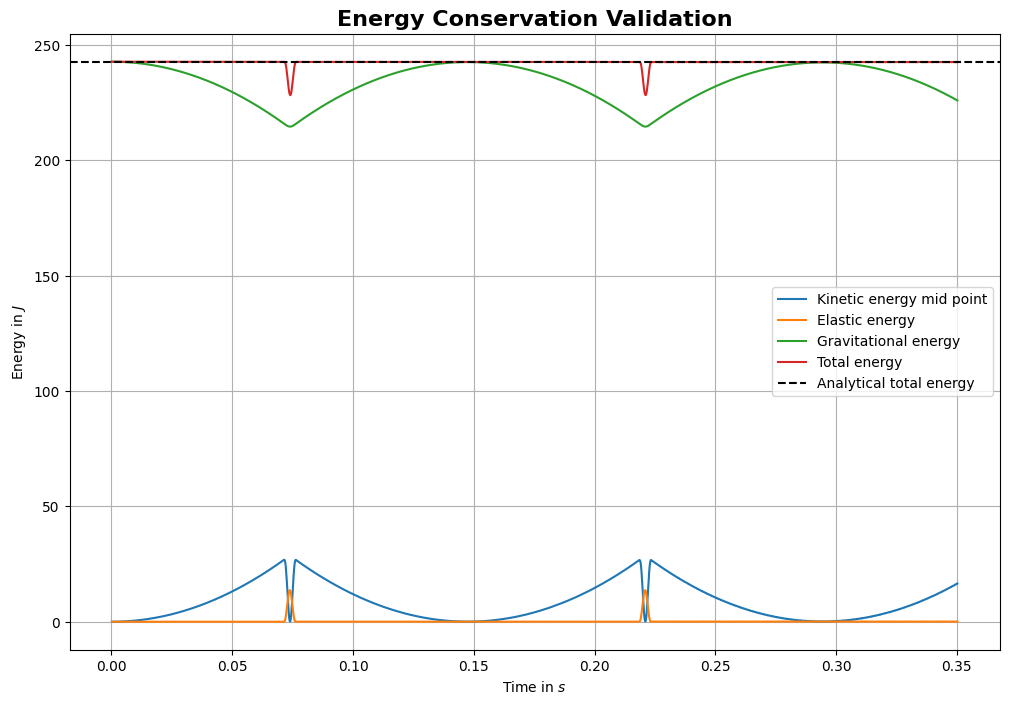

In [106]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.title("Energy Conservation Validation", fontsize=16,  fontweight='bold')
plt.plot(time_hist, E_kin_mid_hist, label="Kinetic energy mid point")
plt.plot(time_hist, E_ela_hist, label="Elastic energy")
plt.plot(time_hist, E_grav_hist, label="Gravitational energy")
plt.plot(time_hist, E_tot_hist, label="Total energy")
plt.axhline(E_tot_analytical, color='k', linestyle='--', label="Analytical total energy")
plt.xlabel("Time in $s$")
plt.ylabel("Energy in $J$")
plt.legend()
plt.grid()
plt.show()


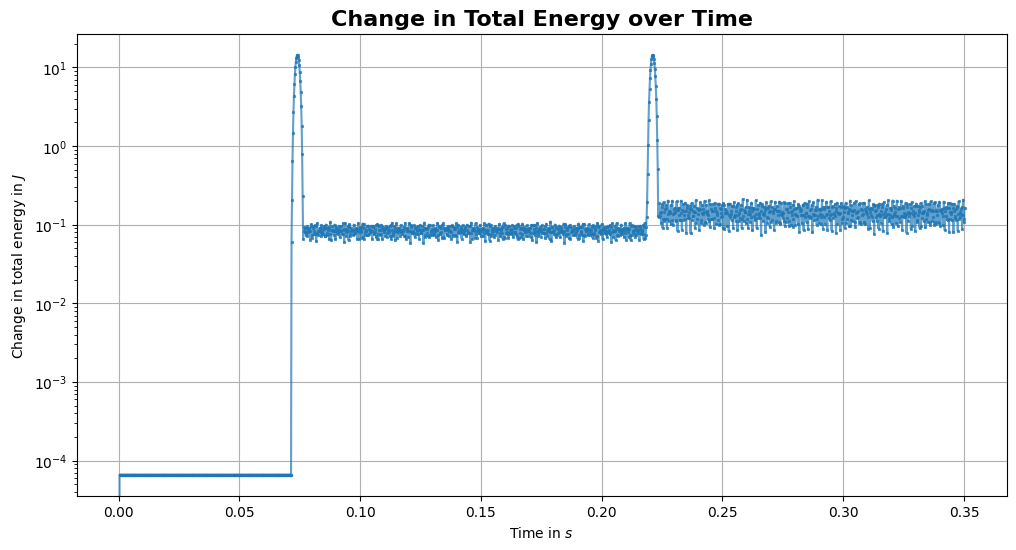

In [107]:
delta_E_tot = np.abs(np.array(E_tot_hist) - E_tot_hist[0])
plt.figure(figsize=(12,6))
plt.title("Change in Total Energy over Time", fontsize=16,  fontweight='bold')
plt.semilogy(time_hist, delta_E_tot, marker='*', markersize=2, alpha=0.7)
plt.xlabel("Time in $s$")
plt.ylabel("Change in total energy in $J$")
plt.grid()
plt.show()

In [108]:
E_tot_start = E_tot_hist[0]
e_tot_end = E_tot_hist[-1]
delta_e_tot = E_tot_start - e_tot_end

rel_error = np.abs(delta_e_tot) / np.abs(E_tot_start)
print(f"Relative error in total energy: {rel_error*100:.6f} %")
print(f"Change in total energy: {delta_e_tot:.6f} J")

Relative error in total energy: 0.067570 %
Change in total energy: 0.163992 J


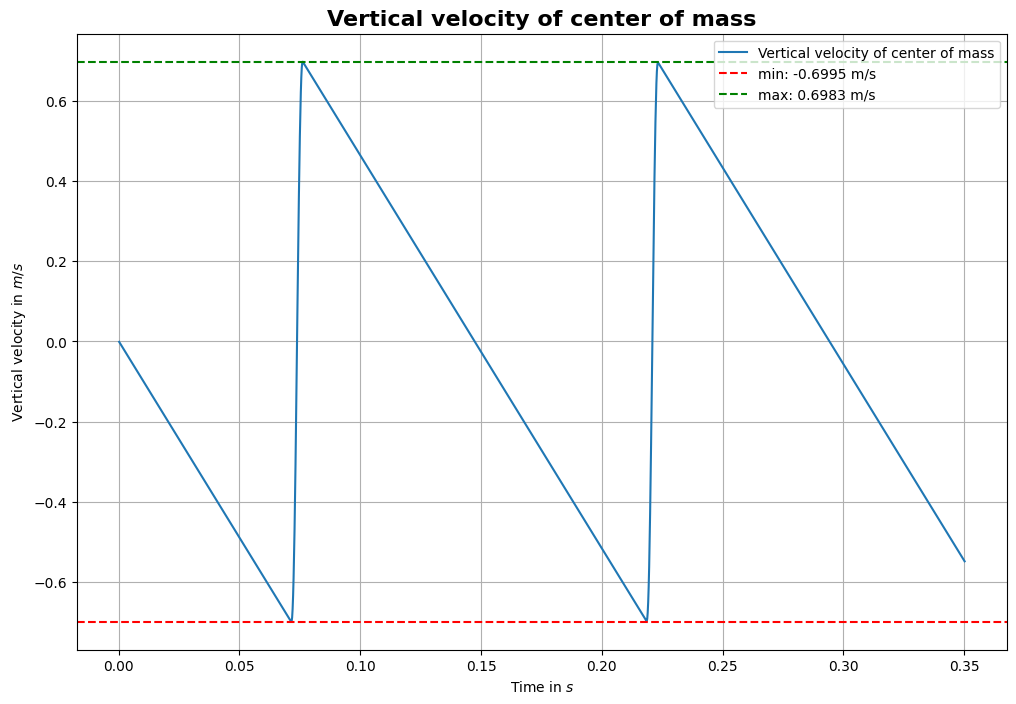

In [109]:
v_min = min(vy_cm_hist)
v_max = max(vy_cm_hist)

plt.figure(figsize=(12,8))
plt.title("Vertical velocity of center of mass", fontsize=16,  fontweight='bold')
plt.plot(time_hist, vy_cm_hist, label="Vertical velocity of center of mass")
plt.axhline(v_min, color='red', linestyle='--', label=f"min: {v_min:.4f} m/s")
plt.axhline(v_max, color='green', linestyle='--', label=f"max: {v_max:.4f} m/s")
plt.xlabel("Time in $s$")
plt.ylabel("Vertical velocity in $m/s$")
plt.legend()
plt.grid()
plt.show()

In [110]:
error_abs = abs(v_max - np.sqrt(2*g*(h0_ball-r_ball-rect_len_y)))
error_rel = error_abs / abs(v_max)
print(f"Error in impact velocity: {error_abs:.6f} m/s")
print(f"Relative error in impact velocity: {error_rel*100:.4f} %")

Error in impact velocity: 0.002089 m/s
Relative error in impact velocity: 0.2992 %
